# Analyse de Fourier d'un signal périodique

Ce notebook implémente le calcul des **coefficients de Fourier complexes** $C_k$ d'un signal périodique,
en utilisant la **méthode de Simpson** pour l'intégration numérique.

## Rappel théorique

Tout signal périodique $f(x)$ de période $T_0$ peut s'écrire comme une somme de sinusoïdes complexes :

$$f(x) = \sum_{k=-\infty}^{+\infty} C_k \cdot e^{jk\omega_0 x}$$

où $\omega_0 = \frac{2\pi}{T_0}$ est la **pulsation fondamentale**, et les coefficients $C_k$ sont calculés par :

$$C_k = \frac{1}{T_0} \int_0^{T_0} f(x) \cdot e^{-jk\omega_0 x} \, dx$$

## 1. Imports et paramètres

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Période du signal
period = 2 * np.pi

## 2. Définition du signal

On travaille ici avec un signal sinusoïdal simple : $f(x) = \sin(x)$

> Pour tester avec un autre signal, il suffit de modifier la fonction `func`.

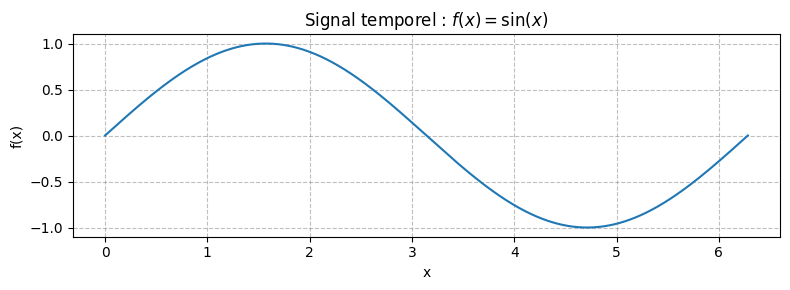

In [3]:
def func(x):
    return np.sin(x)

# Génération de l'axe temporel — nombre de points impair (requis par la méthode de Simpson)
x_axis = np.linspace(0, 2 * np.pi, 1001)
y_axis = func(x_axis)

# Visualisation du signal
plt.figure(figsize=(8, 3))
plt.plot(x_axis, y_axis)
plt.title('Signal temporel : $f(x) = \\sin(x)$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Intégration numérique — Méthode de Simpson

La méthode de Simpson approche l'intégrale en ajustant une **parabole** sur chaque groupe de 3 points consécutifs :

$$\int_a^b f(x)\,dx \approx \frac{h}{3} \sum_{i=0,2,4,...} \left[ y_i + 4y_{i+1} + y_{i+2} \right]$$

où $h$ est le pas entre deux points consécutifs.

> **Contrainte** : le nombre d'intervalles doit être **pair** (donc un nombre de points **impair**).

In [4]:
def integration(x, y):
    """Intègre y(x) par la méthode de Simpson composite.
    
    Paramètres
    ----------
    x : array  Points de l'axe temporel (régulièrement espacés)
    y : array  Valeurs du signal (peut être complexe)
    
    Retourne
    --------
    float ou complex : valeur approchée de l'intégrale
    """
    h = x[1] - x[0]  # pas constant car linspace
    somme = 0
    for i in range(0, len(x) - 2, 2):  # pas de 2 : on prend les triplets
        somme += (h / 3) * (y[i] + 4 * y[i+1] + y[i+2])
    return somme

## 4. Calcul des coefficients de Fourier $C_k$

Pour chaque ordre $k$, on calcule :

$$C_k = \frac{1}{T_0} \int_0^{T_0} f(x) \cdot e^{-jk\omega_0 x} \, dx$$

Le coefficient $C_0$ (composante continue = moyenne du signal) est calculé séparément.

In [5]:
def sig_to_coeff(x, y, N):
    """Calcule les N premiers coefficients de Fourier complexes du signal y(x).
    
    Retourne
    --------
    C0     : coefficient d'ordre 0 (composante continue)
    Coeff  : liste des coefficients C1, C2, ..., CN
    """
    w0 = 2 * np.pi / period

    # C0 : moyenne du signal (e^0 = 1, donc y0 = y)
    C0 = (1 / period) * integration(x, y)

    # Ck pour k = 1 à N
    Coeff = []
    for k in range(1, N + 1):
        yk = y * np.exp(-1j * k * w0 * x)  # produit point à point
        Ck = (1 / period) * integration(x, yk)
        Coeff.append(Ck)

    return C0, Coeff


# Calcul pour les N premiers ordres
N = 10
C0, FC = sig_to_coeff(x_axis, y_axis, N)

# Construction des spectres bilatéraux (de -N à +N)
# Symétrie hermitienne : C_{-k} = C_k*  =>  |C_{-k}| = |C_k|  et  arg(C_{-k}) = -arg(C_k)
modules   = np.concatenate([np.flip(np.abs(FC)),    [np.abs(C0)],    np.abs(FC)])
arguments = np.concatenate([np.flip(-np.angle(FC)), [np.angle(C0)],  np.angle(FC)])

# Suppression du bruit numérique sur la phase (les Ck ≈ 0 ont une phase arbitraire)
seuil = 1e-6
arguments[modules < seuil] = 0

## 5. Visualisation du spectre fréquentiel

On trace le **spectre d'amplitude** $|C_k|$ et le **spectre de phase** $\arg(C_k)$ en fonction de l'ordre $k$.

Pour $f(x) = \sin(x)$, on s'attend à :
- **Amplitude** : deux pics en $k = \pm 1$, valeur $0.5$, tout le reste à zéro
- **Phase** : $-\pi/2$ en $k = +1$ et $+\pi/2$ en $k = -1$

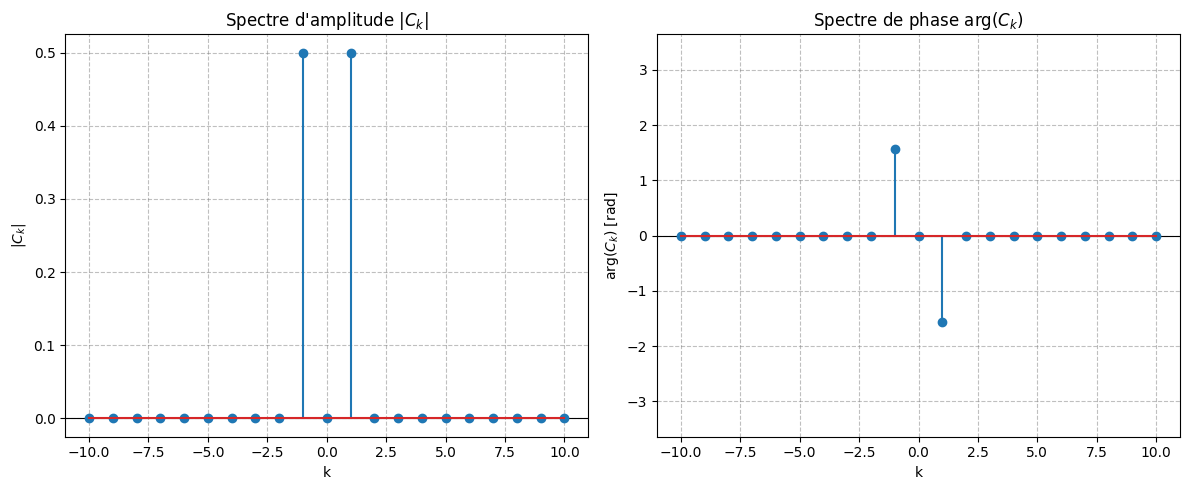

In [6]:
k_axis = np.arange(-N, N + 1)  # axe des ordres : de -N à +N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Spectre d'amplitude ---
ax1.axhline(y=0, color='k', linewidth=0.8)
ax1.stem(k_axis, modules)
ax1.set_title('Spectre d\'amplitude $|C_k|$')
ax1.set_xlabel('k')
ax1.set_ylabel('$|C_k|$')
ax1.grid(True, linestyle='--', color='gray', alpha=0.5)

# --- Spectre de phase ---
ax2.axhline(y=0, color='k', linewidth=0.8)
ax2.stem(k_axis, arguments)
ax2.set_title('Spectre de phase $\\arg(C_k)$')
ax2.set_xlabel('k')
ax2.set_ylabel('$\\arg(C_k)$ [rad]')
ax2.set_ylim(-np.pi - 0.5, np.pi + 0.5)
ax2.grid(True, linestyle='--', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()